<a href="https://colab.research.google.com/github/shahadali-byte/PandTaskApp/blob/main/project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Sanity check ∫ 1 dt over [0, 2π] ≈ 6.283185307179586   (true = 6.283185307179586 )
Sanity check ∫ 1 dt over [0, 2π] ≈ 6.283185307179586   (true = 6.283185307179586 )
Number of basis functions: 5
Coefficient matrix A:
 [[   6.283185   19.739209   82.684448   -0.          0.      ]
 [  19.739209   82.684448  389.646203   -0.         -6.282663]
 [  82.684448  389.646203 1958.60841    12.567415  -39.475138]
 [  -0.         -0.         12.567415    3.141593    0.      ]
 [   0.         -6.282663  -39.475138    0.          3.141593]] 

Right-hand side vector b:
 [ -0.04863   -6.41396  -38.041593   0.111015   3.163905] 

Solved coefficients c:
 [ 2.339775 -2.258074  0.360681 -1.407507  1.023406]
RMSE vs true signal: 0.1791   MAE: 0.1570


/tmp/ipython-input-2464231331.py:52: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(y_values, x_values)
/tmp/ipython-input-2464231331.py:82: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(y_values, x_values)


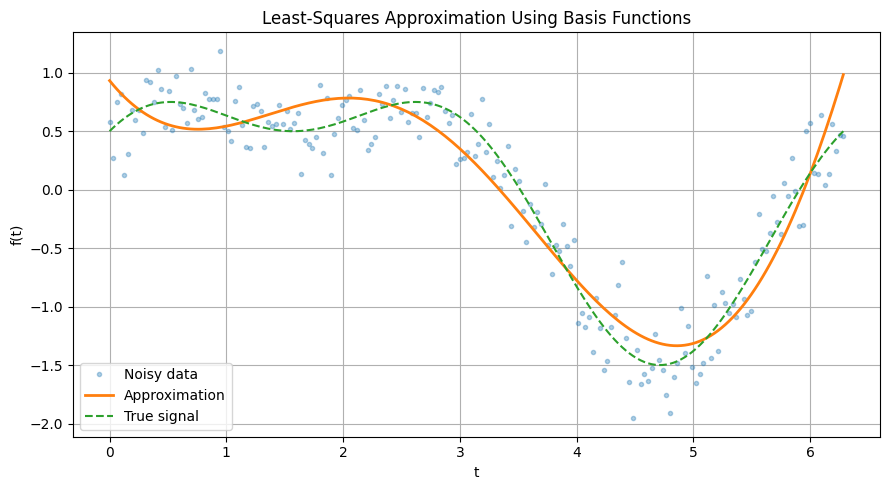

Basis to write by hand: 1, t, t^2, cos t, sin t

Write this on paper:
A c = b, where A_ij = ∫_a^b u_i(t) u_j(t) dt and b_i = ∫_a^b u_i(t) f(t) dt.
For your chosen basis {u1,...,u5} = {1, t, t^2, cos t, sin t}:
  [<1, 1>  <1, t>  <1, t^2>  <1, cos t>  <1, sin t>]  *  c1
  [<t, 1>  <t, t>  <t, t^2>  <t, cos t>  <t, sin t>]
  [<t^2, 1>  <t^2, t>  <t^2, t^2>  <t^2, cos t>  <t^2, sin t>]
  [<cos t, 1>  <cos t, t>  <cos t, t^2>  <cos t, cos t>  <cos t, sin t>]
  [<sin t, 1>  <sin t, t>  <sin t, t^2>  <sin t, cos t>  <sin t, sin t>]

Right-hand side b entries: [<1, f>, <t, f>, <t^2, f>, <cos t, f>, <sin t, f>]^T
Use a = 0 and b = 2π. You do NOT need to evaluate these integrals by hand.


In [3]:
# =========================
# Project 1 - Applied Linear Algebra
# =========================
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=6, suppress=True)  # clean numeric printing
rng = np.random.default_rng(42)                  # fixed seed for reproducibility

# -------------------------
# 1) Time grid and synthetic data
# -------------------------
# Interval [a, b] over which we approximate. Keep this consistent across all integrals.
a, b = 0.0, 2.0 * np.pi

# Number of sample points for evaluating functions and doing numerical integration.
# More points -> better integral accuracy. Keep >= 200 for smoothness.
n_points = 200
t = np.linspace(a, b, n_points)

# Choose a "true" underlying signal for demonstration. This can be any smooth function.
f_true = np.sin(t) + 0.5 * np.cos(2 * t)

# Add Gaussian noise to simulate measurements. This is your "noisy time series".
noise_std = 0.25
f_noisy = f_true + noise_std * rng.standard_normal(n_points)

# -------------------------
# 2) Numerical integration
# -------------------------
# The project asks you to "program an integral". We'll use the trapezoidal rule.
# It approximates ∫ y(x) dx over the given x-grid.
# We wrap np.trapz for clarity and to keep the function name explicit in screenshots.

def integrate_trap(y_values, x_values):
    """
    Compute the definite integral of y(x) given tabulated values (x_values, y_values)
    using the trapezoidal rule.

    Parameters
    ----------
    y_values : array-like
        Values of the integrand evaluated on x_values.
    x_values : array-like
        Monotone grid over [a, b].

    Returns
    -------
    float
        Approximation to ∫_a^b y(x) dx.
    """
    return np.trapz(y_values, x_values)

# Quick sanity check: ∫_0^{2π} 1 dt = 2π
check = integrate_trap(np.ones_like(t), t)
print("Sanity check ∫ 1 dt over [0, 2π] ≈", check, "  (true =", 2*np.pi, ")")

# -------------------------
# 2) Numerical integration
# -------------------------
# The project asks you to "program an integral". We'll use the trapezoidal rule.
# It approximates ∫ y(x) dx over the given x-grid.
# We wrap np.trapz for clarity and to keep the function name explicit in screenshots.

def integrate_trap(y_values, x_values):
    """
    Compute the definite integral of y(x) given tabulated values (x_values, y_values)
    using the trapezoidal rule.

    Parameters
    ----------
    y_values : array-like
        Values of the integrand evaluated on x_values.
    x_values : array-like
        Monotone grid over [a, b].

    Returns
    -------
    float
        Approximation to ∫_a^b y(x) dx.
    """
    return np.trapz(y_values, x_values)

# Quick sanity check: ∫_0^{2π} 1 dt = 2π
check = integrate_trap(np.ones_like(t), t)
print("Sanity check ∫ 1 dt over [0, 2π] ≈", check, "  (true =", 2*np.pi, ")")

# -------------------------
# 3) Basis functions
# -------------------------
# You must choose at least 5. Below is a mixed polynomial-trigonometric set.
# You can change these, but keep them independent over [a, b].

def u1(x): return np.ones_like(x)     # 1
def u2(x): return x                    # t
def u3(x): return x**2                 # t^2
def u4(x): return np.cos(x)            # cos t
def u5(x): return np.sin(x)            # sin t

basis = [u1, u2, u3, u4, u5]
m = len(basis)
print("Number of basis functions:", m)

# -------------------------
# 4) Inner products and linear system A c = b
# -------------------------
# We define the L2 inner product on [a, b]:
#   <u_i, u_j> = ∫_a^b u_i(t) u_j(t) dt
#   <u_i, f>   = ∫_a^b u_i(t) f_noisy(t) dt
# We compute these integrals numerically using integrate_trap defined above.

A = np.zeros((m, m))
b_vec = np.zeros(m)

# Fill the matrix A and vector b by numerical integration on the sampling grid.
for i in range(m):
    ui_vals = basis[i](t)
    for j in range(m):
        uj_vals = basis[j](t)
        A[i, j] = integrate_trap(ui_vals * uj_vals, t)  # <u_i, u_j>
    b_vec[i] = integrate_trap(ui_vals * f_noisy, t)      # <u_i, f>

print("Coefficient matrix A:\n", A, "\n")
print("Right-hand side vector b:\n", b_vec, "\n")

# -------------------------
# 5) Solve linear system for coefficients
# -------------------------
# This yields the least-squares projection of f_noisy onto span{u1,...,um}.
# We assume A is well-conditioned for this basis on [a,b].

c = np.linalg.solve(A, b_vec)
print("Solved coefficients c:\n", c)

# -------------------------
# 6) Construct the approximation on the grid
# -------------------------
f_approx = np.zeros_like(t)
for k in range(m):
    f_approx += c[k] * basis[k](t)

# Optional: compute simple error metrics against the known f_true for your report.
rmse = np.sqrt(np.mean((f_approx - f_true)**2))
mae  = np.mean(np.abs(f_approx - f_true))
print(f"RMSE vs true signal: {rmse:.4f}   MAE: {mae:.4f}")

# -------------------------
# 7) Visualization (deliverable)
# -------------------------
# This plot should be included in your single PDF submission.

plt.figure(figsize=(9,5))
plt.plot(t, f_noisy, 'o', ms=3, alpha=0.35, label="Noisy data")
plt.plot(t, f_approx, '-', lw=2, label="Approximation")
plt.plot(t, f_true, '--', lw=1.5, label="True signal")
plt.xlabel("t")
plt.ylabel("f(t)")
plt.title("Least-Squares Approximation Using Basis Functions")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Optional: save the plot as a file for your PDF
# plt.savefig("project1_plot.png", dpi=200, bbox_inches="tight")

# -------------------------
# 8) Symbolic template for your handwritten page
# -------------------------
# The project requires a handwritten page listing the basis and the matrix system
# with inner products shown as integrals. We print a template you can copy by hand.

basis_names = ["1", "t", "t^2", "cos t", "sin t"]
print("Basis to write by hand:", ", ".join(basis_names))
print("\nWrite this on paper:")
print("A c = b, where A_ij = ∫_a^b u_i(t) u_j(t) dt and b_i = ∫_a^b u_i(t) f(t) dt.")
print("For your chosen basis {u1,...,u5} = {1, t, t^2, cos t, sin t}:")

for i, ui in enumerate(basis_names, start=1):
    row = []
    for j, uj in enumerate(basis_names, start=1):
        row.append(f"<{ui}, {uj}>")
    print("  [" + "  ".join(row) + "]  *  c{}".format(i) if i==1 else "  [" + "  ".join(row) + "]")

print("\nRight-hand side b entries: [<1, f>, <t, f>, <t^2, f>, <cos t, f>, <sin t, f>]^T")
print("Use a = 0 and b = 2π. You do NOT need to evaluate these integrals by hand.")


